Importing dependencies

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

Loading the MNIST data from keras.dataset

In [72]:
(x_train, y_train), (x_test,y_test) = mnist.load_data()

In [73]:
type(x_train)

numpy.ndarray

In [74]:
# shape of the numpy arrays
print(x_train.shape, y_train.shape,x_test.shape,y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


Training data = 60000 images

Test data = 10000 images

Image dimension : 28 x 28

Grayscale image --> one color channel

In [75]:
# printing the 10th image
print(x_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [76]:
print(x_train[10].shape)

(28, 28)


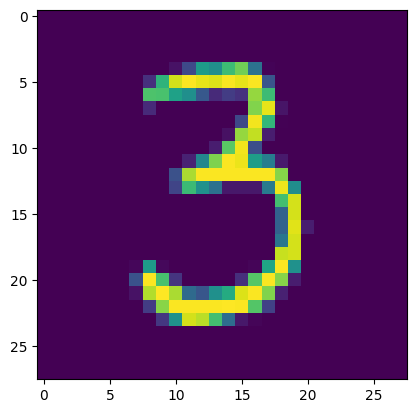

2


In [77]:
# displaying the image

plt.imshow(x_train[50])
plt.show()

# print the corresponding label
print(y_train[25])

Image labels

In [78]:
print(y_train.shape,y_test.shape)

(60000,) (10000,)


In [79]:
# unique values in y_train
print(np.unique(y_train))

print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


we can use these labels as such or we can also apply One Hot Encoding

All the images have the same dimensions in this dataset. If not we have to resize all the images to a common dimensions

In [80]:
# scaling the values

x_train = x_train/255
x_test = x_test/255

print(x_train[10])


[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

Building the neural network

In [81]:
# setting up the layers of the neural network
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [82]:
#  compiling the neural network
model.compile(optimizer='adam',
loss = 'sparse_categorical_crossentropy',
               metrics=['accuracy'])

In [83]:
# traing the neural network

model.fit(x_train,y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9148 - loss: 0.2905
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9589 - loss: 0.1364
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9698 - loss: 0.0991
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9762 - loss: 0.0782
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9811 - loss: 0.0628
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9844 - loss: 0.0520
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9872 - loss: 0.0436
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9889 - loss: 0.0374
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9902 - loss: 0.0327
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9910 - loss: 0.0289


Training data accuracy is 98.9%

Accuracy on test data

In [84]:
loss, accuracy = model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9704 - loss: 0.1175


In [85]:
print(accuracy)

0.9703999757766724


Test data accuracy is 97.1%

In [86]:
print(x_test.shape)

(10000, 28, 28)


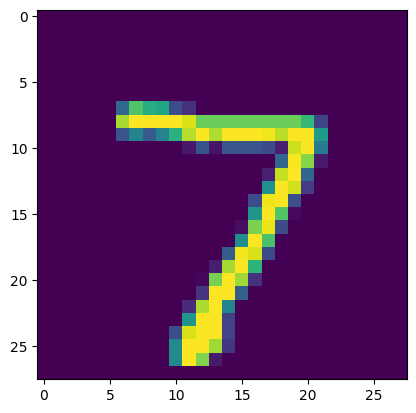

In [87]:
# first data point in x_test
plt.imshow(x_test[0])
plt.show()

In [88]:
print(y_test[0])

7


In [89]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [90]:
print(y_pred.shape)

(10000, 10)


In [91]:
print(y_pred[0])

[6.1115189e-03 2.9971742e-04 2.8436759e-02 9.8583597e-01 3.7552305e-05
 2.3606753e-01 1.0459031e-10 9.9999940e-01 7.2847116e-01 9.7948927e-01]


model.predict() gives the prediction probability of each class for that particular datapoint

In [92]:
# converting the prediction probabilities to class label
label_for_first_test_image = np.argmax(y_pred[0])

In [93]:
print(label_for_first_test_image)

7


In [94]:
# converting the prediction probabilities to class label for all test datapoints
y_pred_labels = [int(np.argmax(i)) for i in y_pred]
print(y_pred_labels)

[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5, 4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2, 4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3, 7, 4, 6, 4, 3, 0, 7, 0, 3, 9, 1, 7, 3, 2, 9, 7, 7, 6, 2, 7, 8, 4, 7, 3, 6, 1, 3, 6, 9, 3, 1, 4, 1, 7, 6, 9, 6, 0, 5, 4, 9, 9, 2, 1, 9, 4, 8, 7, 3, 9, 7, 4, 4, 4, 9, 2, 5, 4, 7, 6, 7, 9, 0, 5, 8, 5, 6, 6, 5, 7, 8, 1, 0, 1, 6, 4, 6, 7, 3, 1, 7, 1, 8, 2, 0, 1, 9, 8, 5, 5, 1, 5, 6, 0, 3, 4, 4, 6, 5, 4, 6, 5, 4, 5, 1, 4, 4, 7, 2, 3, 2, 7, 1, 8, 1, 8, 1, 8, 5, 0, 8, 9, 2, 5, 0, 1, 1, 1, 0, 8, 0, 3, 1, 6, 4, 2, 3, 6, 1, 1, 1, 3, 9, 5, 2, 9, 4, 5, 9, 3, 9, 0, 3, 6, 5, 5, 7, 2, 2, 7, 1, 2, 8, 4, 1, 7, 3, 3, 8, 8, 7, 9, 2, 2, 4, 1, 5, 9, 8, 7, 2, 3, 0, 6, 4, 2, 4, 1, 9, 5, 7, 7, 2, 8, 2, 0, 8, 5, 7, 7, 9, 1, 8, 1, 8, 0, 3, 0, 1, 9, 3, 4, 1, 8, 2, 1, 2, 9, 7, 5, 9, 2, 6, 4, 1, 5, 8, 2, 9, 2, 0, 4, 0, 0, 2, 8, 4, 7, 1, 2, 4, 0, 2, 7, 4, 3, 3, 0, 0, 3, 1, 9, 6, 5, 3, 5, 8, 7, 9, 3, 0, 4, 2, 0, 7, 1, 1, 2, 1, 

In [95]:
print(y_pred)

[[6.1115189e-03 2.9971742e-04 2.8436759e-02 ... 9.9999940e-01
  7.2847116e-01 9.7948927e-01]
 [4.3632466e-05 9.9560267e-01 9.9999988e-01 ... 2.8795583e-10
  2.6860939e-02 1.4298443e-10]
 [6.5665467e-05 9.9967104e-01 3.2686148e-02 ... 7.6040435e-01
  3.3320007e-01 1.0802889e-03]
 ...
 [2.0245022e-08 2.3617093e-04 1.0185623e-08 ... 8.9439058e-01
  3.2588542e-02 9.9992853e-01]
 [3.1094973e-05 3.0347146e-06 6.7282329e-08 ... 9.5375802e-04
  9.8543221e-01 8.0993443e-09]
 [2.3495202e-06 6.2070911e-05 3.8307863e-01 ... 1.5839876e-12
  1.2377597e-01 1.3568600e-06]]


y_test ---> True labels

y_pred_labels ---> predicted labels by neural network

Confusion matrix

In [96]:
conf_matx = confusion_matrix(y_test,y_pred_labels)

In [97]:
print(conf_matx)

tf.Tensor(
[[ 956    0    2    1    3    3    3    1    2    9]
 [   0 1118    1    4    2    0    3    2    5    0]
 [   3    2  975   20    4    0    6   12    9    1]
 [   0    0    2  990    1    4    0    4    3    6]
 [   4    0    0    0  946    4    9    5    2   12]
 [   2    0    0   11    1  863    4    1    4    6]
 [   4    2    1    0    2    7  940    1    1    0]
 [   1    2    5    8    1    0    0  989    2   20]
 [   3    0    1    6    1    5    2    3  942   11]
 [   0    0    0    2    9    4    1    0    8  985]], shape=(10, 10), dtype=int32)


Text(0.5, 47.7222222222222, 'Predicted Labels')

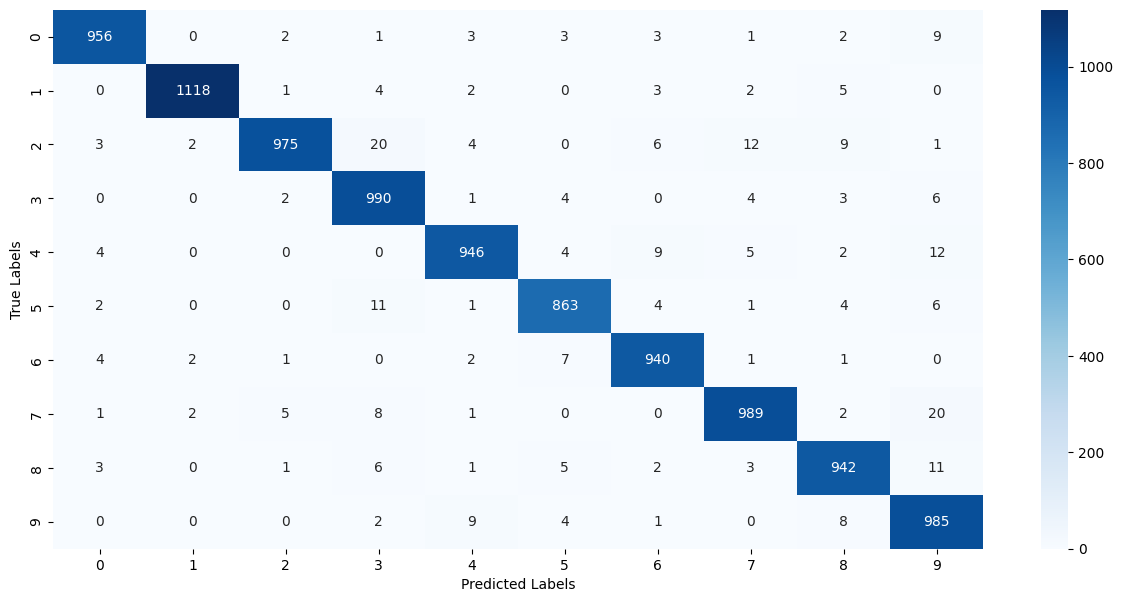

In [98]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_matx,annot=True,fmt='d',cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

Building a predictive system

In [99]:
input_image_path = "/content/sample_data/MNIST_digit.png"

input_image = cv2.imread(input_image_path)

In [100]:
type(input_image)

numpy.ndarray

In [101]:
print(input_image)

[[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]


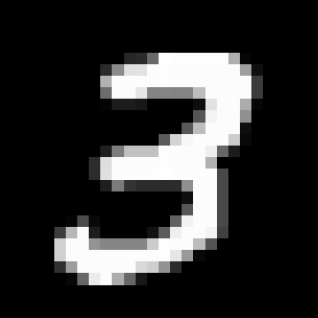

In [118]:
cv2_imshow(input_image)

In [103]:
input_image.shape

(318, 318, 3)

In [104]:
grayscale = cv2.cvtColor(input_image,cv2.COLOR_RGB2GRAY)


In [105]:
grayscale.shape

(318, 318)

In [106]:
input_image_resized = cv2.resize(grayscale,(28,28))

In [107]:
input_image_resized.shape

(28, 28)

In [117]:
cv2_imshow(input_image_resized)

In [109]:
input_image_resized = input_image_resized/255

In [110]:
type(input_image_resized)

numpy.ndarray

In [111]:
image_reshaped = np.reshape(input_image_resized,[1,28,28])


In [112]:
input_prediction = model.predict(image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[[3.0225031e-10 1.4405197e-03 4.9202648e-05 1.0000000e+00 1.3129180e-09
  3.6616558e-01 1.4790224e-20 8.9821249e-02 8.8661689e-01 6.2970906e-02]]


In [113]:
input_pred_label = np.argmax(input_prediction)

In [114]:
print(input_pred_label)

3


Predictive system

In [121]:
input_imgage_path = input(' Enter path of the image to be predicted')
input_image = cv2.imread(input_imgage_path)
grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)
input_image_resized = input_image_resized/255
input_image_resized = input_image_resized/255
input_prediction = model.predict(image_reshaped)
print('The hand written digit is recognized as',input_pred_label)

 Enter path of the image to be predicted/content/sample_data/MNIST_digit.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
The hand written digit is recognized as 3
